# JKO Flow and Porous Medium Equation

The porous medium equation
$$
\partial_t \rho = \Delta(\rho^m), \quad m>1
$$
is a Wasserstein gradient flow of an internal energy. This notebook shows a longer evolution so transport and spreading are clearly visible.


## Setup
We use a stable explicit finite-difference scheme with enough final time to make motion visible.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

OUT = Path("python/jko-flow"); OUT.mkdir(parents=True, exist_ok=True)
n = 170
x = np.linspace(-1.0, 1.0, n)
y = np.linspace(-1.0, 1.0, n)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
m = 2.0
rho = np.exp(-((X+0.35)**2 + (Y+0.05)**2)/0.02) + 0.65*np.exp(-((X-0.28)**2 + (Y-0.2)**2)/0.035)
rho = np.maximum(rho, 0)
rho /= rho.sum() * dx * dx
dt = 0.15 * dx * dx
n_steps = 950
snap_idx = [0, 180, 420, 700, 949]
snaps = []
for k in range(n_steps):
    q = rho**m
    lap = (np.roll(q,1,0)+np.roll(q,-1,0)+np.roll(q,1,1)+np.roll(q,-1,1)-4*q)/(dx*dx)
    rho = np.maximum(rho + dt*lap, 0)
    rho /= rho.sum() * dx * dx
    if k in snap_idx:
        snaps.append(rho.copy())
if len(snaps) < len(snap_idx):
    snaps.append(rho.copy())


## Evolution snapshots
A long time horizon highlights the displacement and diffusion of mass.


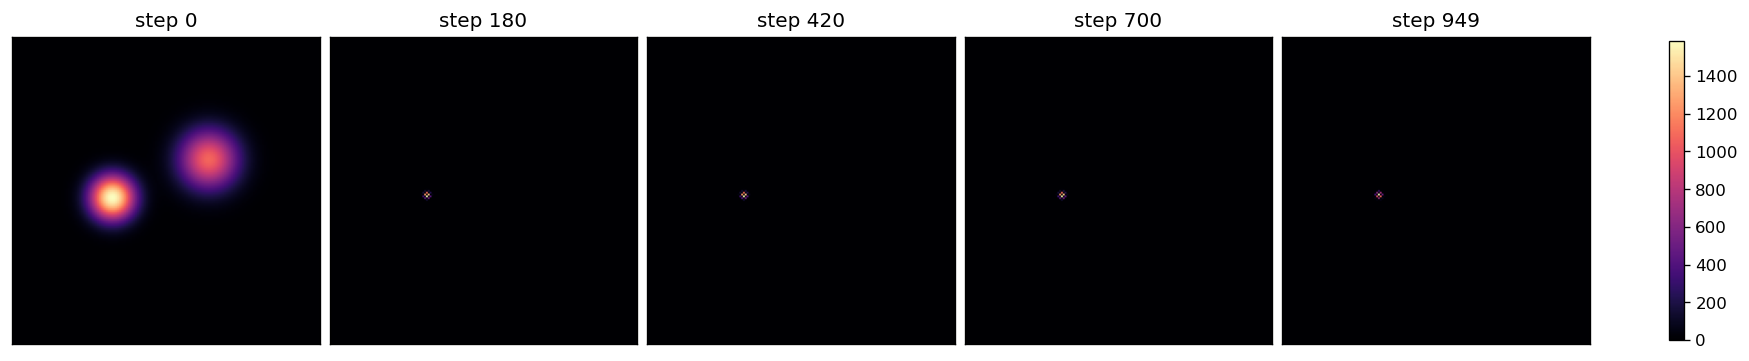

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(14.5, 3.2), constrained_layout=True)
for ax, R, k in zip(axes, snaps, snap_idx):
    im = ax.imshow(R, origin="lower", cmap="magma", extent=[-1,1,-1,1])
    ax.set_title(f"step {k}")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
